# AstroCLIMB - Gemma-4-E4B Baseline (Kaggle Ready, No Gating)
**Model:** `google/gemma-4-E4B-it` (Gemma 4 family, E4B 4.5B effective / 8B with embeddings, 128K, Apache 2.0). **Filename** `Gemma-4-4B` kept for compatibility. **Kaggle-ready** `GPU T4 x2`, **balanced 1800** `450/class`.
**Gemma 4 is Apache 2.0 (not gated)** — no `Agree` click needed, no `HF_TOKEN` required (token optional for rate limits). Alternative T4-safe: `google/gemma-4-E2B-it` (2.3B). Larger `12B/31B/26B-A4B` will OOM on T4.
**Install:** `transformers>=5.15.1` (required for Gemma4, vs 5.0.0 default). Inline cell auto-installs + `bitsandbytes>=0.46.1`.
**Classes:** `same_figure, same_paper, related_papers, unrelated_papers` - descriptive prompt, image BEFORE text (Gemma4 convention).


In [1]:
# --- 1. Setup + Kaggle-ready install (no manual restart needed) ---
import os, json, time, re, gc, base64, sys, subprocess, importlib
from pathlib import Path
from io import BytesIO
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
print("torch", torch.__version__, "cuda", torch.cuda.is_available())
if torch.cuda.is_available():
    print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("NO GPU - Kaggle: Settings -> Accelerator -> GPU T4 x2 -> Save Version & Rerun")
# Gemma4 requires transformers>=5.15.1 (doc v5.15.1) vs Kaggle default 5.0.0 - install BEFORE import
try:
    import importlib.metadata as im
    ver = im.version("transformers")
    print(f"transformers {ver} found")
    from packaging import version as pv
    need_upgrade = pv.parse(ver) < pv.parse("5.15.1")
except Exception as e:
    ver = "0.0.0"
    need_upgrade = True
if need_upgrade:
    print(f"Upgrading transformers {ver} -> 5.15.1 for Gemma4...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers>=5.15.1", "accelerate"])
    # Clear old modules so new version loads without kernel restart
    for m in list(sys.modules.keys()):
        if m.startswith("transformers"):
            del sys.modules[m]
    import importlib as _il
    _il.invalidate_caches()
import transformers
print(f"transformers {transformers.__version__} ready for Gemma4")
# Auto-fix bitsandbytes
try:
    import bitsandbytes
    print(f"bitsandbytes {bitsandbytes.__version__} OK")
except ImportError:
    print("bitsandbytes missing, installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes>=0.46.1"])
    import bitsandbytes
    print(f"bitsandbytes {bitsandbytes.__version__} installed")


torch 2.10.0+cu128 cuda True
['Tesla T4', 'Tesla T4']
VRAM: 15.6 GB
transformers 5.0.0 found
Upgrading transformers 5.0.0 -> 5.15.1 for Gemma4...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 96.8 MB/s eta 0:00:00
transformers 5.16.1 ready for Gemma4
bitsandbytes missing, installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 28.0 MB/s eta 0:00:00
bitsandbytes 0.50.2 installed


In [2]:
# --- 2. Data loading (Kaggle competitions path, train-only) ---
train = pd.read_csv("/kaggle/input/competitions/astroclimb/train.csv")
print(f"train {train.shape}")
print(train.columns.tolist())
display(train.head(2))
label_cols = ["same_figure","same_paper","related_papers","unrelated_papers"]
train["label"] = train[label_cols].idxmax(axis=1)
train["label_id"] = train["label"].map({c:i for i,c in enumerate(label_cols)})
print(train["label"].value_counts())
print(train[label_cols].sum())


train (10000, 7)
['id', 'same_figure', 'same_paper', 'related_papers', 'unrelated_papers', 'obj_1', 'obj_2']


,id,same_figure,same_paper,related_papers,unrelated_papers,obj_1,obj_2
0,0,1,0,0,0,Distribution of the RVs for TOI-2046b in the t...,iVBORw0KGgoAAAANSUhEUgAACVYAAAZUCAIAAACPYVwUAA...
1,1,1,0,0,0,Vertical structures of the Martian background ...,iVBORw0KGgoAAAANSUhEUgAABwgAAAQ2CAIAAACoaX6RAA...


label
same_paper          3000
related_papers      3000
unrelated_papers    3000
same_figure         1000
Name: count, dtype: int64
same_figure         1000
same_paper          3000
related_papers      3000
unrelated_papers    3000
dtype: int64


In [3]:
# --- 3. Helpers: detect image vs text + decode (train only) ---
def is_image_str(s):
    if not isinstance(s, str) or len(s) < 200:
        return False
    return s.strip().startswith("iVBORw0KGgo")  # PNG base64 header (JPEG would be /9j/)

def convert_str_to_PIL(img_str):
    return Image.open(BytesIO(base64.b64decode(img_str))).convert("RGB")

train["obj_1_is_img"] = train["obj_1"].apply(is_image_str)
train["obj_2_is_img"] = train["obj_2"].apply(is_image_str)
train["pair_type"] = train.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
print(train["pair_type"].value_counts())


pair_type
TXT-IMG    4000
IMG-IMG    3000
TXT-TXT    3000
Name: count, dtype: int64


In [4]:
# --- 3b. Balanced sampler for 5-7h session (per-class + pairwise per class) ---
# 5-7h = 1500-2100 samples at 12s/it. Choose 450/class => 1800 total = ~6.3h (center)
# same_figure only has TXT-IMG (1000 total), so it will be 450 TXT-IMG / 0 others. Others: 150 per pair_type.
def sample_balanced(df, n_per_class=450, seed=42):
    import pandas as pd
    assert n_per_class % 3 == 0, "n_per_class must be divisible by 3 for 3-type classes"
    parts = []
    for label in ["same_figure","same_paper","related_papers","unrelated_papers"]:
        sub = df[df["label"]==label]
        if label == "same_figure":
            # Only TXT-IMG exists for same_figure
            parts.append(sub[sub["pair_type"]=="TXT-IMG"].sample(n=n_per_class, random_state=seed))
        else:
            per_pair = n_per_class // 3
            for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
                g = sub[sub["pair_type"]==pt]
                if len(g) < per_pair:
                    print(f"Warning: {label} {pt} has {len(g)} < {per_pair}, taking all")
                    parts.append(g)
                else:
                    parts.append(g.sample(n=per_pair, random_state=seed))
    bal = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return bal

train_bal = sample_balanced(train, n_per_class=450, seed=42)
print(f"train_bal {train_bal.shape} (target 1800 = 450*4)")
print(train_bal["label"].value_counts())
print(pd.crosstab(train_bal["label"], train_bal["pair_type"]))
print(f"Estimated time: {len(train_bal)*12.5/3600:.1f}h at 12.5s/it")


train_bal (1800, 12) (target 1800 = 450*4)
label
unrelated_papers    450
related_papers      450
same_paper          450
same_figure         450
Name: count, dtype: int64
pair_type         IMG-IMG  TXT-IMG  TXT-TXT
label                                      
related_papers        150      150      150
same_figure             0      450        0
same_paper            150      150      150
unrelated_papers      150      150      150
Estimated time: 6.2h at 12.5s/it


### 4. Task (multi-class, single-label, symmetrical)
Inputs = pairs of objects: `two figures` / `figure + caption` / `two captions`. Exactly **one** label per pair, relation is symmetrical (A vs B == B vs A).

- **same_figure**: two objects are from the SAME scientific figure (only for figure+caption pairs)
- **same_paper**: same paper (same DOI), different figures
- **related_papers**: one DOI cites the other
- **unrelated_papers**: none of the above

Train has only `obj_1, obj_2` + 4 one-hot label cols -> model must infer DOI/citation **from content only** (no metadata). System prompt below is **descriptive**, not hard constraints; test hood unknown so we do not mask labels.


In [5]:
# Descriptive prompt - no metadata, infer from content only (no DOI leaked, no hard same_figure constraint)
SYSTEM_PROMPT = """You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.
- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.
- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.
- unrelated_papers: No clear link. Different topics, instruments, scales, or writing/visual style with no overlap.

Base your decision only on visual and textual content. Do not assume same_figure is impossible for any pair type - judge from alignment.
Output ONLY the lowercase label (e.g., related_papers), no explanation, no punctuation.
"""

def build_user_content(row):
    parts = []
    for col, name in [("obj_1","Object A"), ("obj_2","Object B")]:
        s = row[col]
        if row[f"{col}_is_img"]:
            parts.append({"name": name, "is_img": True, "pil": convert_str_to_PIL(s)})
        else:
            txt = str(s)[:2000]
            parts.append({"name": name, "is_img": False, "text": txt})
    return parts

print(SYSTEM_PROMPT[:400])
print(build_user_content(train.iloc[0])[0].keys())


You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned ve
dict_keys(['name', 'is_img', 'text'])


In [6]:
# --- 5. Model loading - Gemma-4-E4B (strict, Apache 2.0, no gating) ---
# Model is google/gemma-4-E4B-it (Gemma 4 family, E4B 4.5B effective 8B with embeddings, 128K)
# For even smaller T4 footprint use google/gemma-4-E2B-it (2.3B). 12B/31B/26B-A4B will OOM on T4 15.6GB
from transformers import AutoProcessor
import torch, os
MODEL_ID = "google/gemma-4-E4B-it"  # T4-safe 4B equivalent (Apache 2.0, no Agree needed)
# Alternative: MODEL_ID = "google/gemma-4-E2B-it" # 2.3B ultra-safe
MODEL_ID = MODEL_ID.strip()
ENABLE_THINKING = False  # Gemma4 supports enable_thinking=True for reasoning mode
BATCH_SIZE = 1
MAX_NEW_TOKENS = 32
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL_ID} batch={BATCH_SIZE} thinking={ENABLE_THINKING} on {device}")
if device=="cpu":
    raise SystemExit("Enable GPU T4 x2")
# HF_TOKEN optional for Gemma4 (Apache 2.0 not gated) - only for rate limits
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    print(f"HF_TOKEN found len={len(hf_token)} (optional for Gemma4)")
else:
    print("No HF_TOKEN (ok for Gemma4 Apache 2.0)")
# Gemma4 uses AutoModelForMultimodalLM (transformers 5.15.1) or AutoModelForImageTextToText
try:
    from transformers import AutoModelForMultimodalLM as ModelClass
    print("Using AutoModelForMultimodalLM (Gemma4)")
except ImportError:
    try:
        from transformers import AutoModelForImageTextToText as ModelClass
        print("Using AutoModelForImageTextToText")
    except ImportError:
        from transformers import AutoModel as ModelClass
        print("Fallback AutoModel")
# Processor: Gemma4 needs padding_side left per docs
try:
    processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left", trust_remote_code=True)
except TypeError:
    processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print("Processor loaded", type(processor).__name__)
# Gemma4 vision: fixed-budget soft tokens default 280 (~645K pixels), keep aspect ratio, divisible by 48
# We thumbnail to 448 to stay under budget and fit T4
try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
    model = ModelClass.from_pretrained(MODEL_ID, device_map="auto", quantization_config=bnb_config, max_memory={0:"10GB", 1:"10GB"}, trust_remote_code=True, attn_implementation="sdpa")
    print("Model 4-bit", type(model).__name__)
except Exception as e:
    print(f"4-bit failed {e}, trying bf16 sharded 10GB")
    model = ModelClass.from_pretrained(MODEL_ID, dtype="bfloat16", device_map="auto", max_memory={0:"10GB", 1:"10GB"}, trust_remote_code=True, attn_implementation="sdpa")
    print("Model bf16", type(model).__name__)
model.eval()
print("Has generate:", hasattr(model, 'generate'))


Loading google/gemma-4-E4B-it batch=1 thinking=False on cuda
No HF_TOKEN (ok for Gemma4 Apache 2.0)
Using AutoModelForMultimodalLM (Gemma4)


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

4-bit failed Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. , trying bf16 sharded 10GB


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Some parameters are on the meta device because they were offloaded to the disk.


Model bf16 Gemma4ForConditionalGeneration
Has generate: True


In [7]:
def build_messages_batch(df_batch):
    messages_list = []
    for _, row in df_batch.iterrows():
        parts = build_user_content(row)  # uses only obj_1/obj_2 + is_img
        content = [{"type": "text", "text": SYSTEM_PROMPT + "\n"}]
        for p in parts:
            if p["is_img"]:
                content.append({"type": "image", "image": p["pil"]})
                content.append({"type": "text", "text": "\n" + p["name"] + ": [Figure image]"})
            else:
                content.append({"type": "text", "text": "\n" + p["name"] + " (caption): " + p["text"]})
        content.append({"type": "text", "text": "\nAnswer with one label:"})
        messages_list.append([{"role": "user", "content": content}])
    return messages_list


In [8]:
# --- 6b. Batched inference (Gemma4, image BEFORE text, OOM-safe) ---
import re
from tqdm import tqdm
LABELS = label_cols
label_pattern = re.compile(r"(same_figure|same_paper|related_papers|unrelated_papers)", re.IGNORECASE)
def parse_label(text):
    m = label_pattern.search(text.lower())
    return m.group(1).lower() if m else "unrelated_papers"
def predict_batch(df, batch_size=BATCH_SIZE, save_every=1000, save_path="preds_train.npy"):
    preds = []
    import torch
    for i in tqdm(range(0, len(df), batch_size), desc="Infer"):
        batch = df.iloc[i:i+batch_size]
        # Gemma4: use processor.apply_chat_template with messages (image BEFORE text)
        messages_list = []
        for _, row in batch.iterrows():
            parts = build_user_content(row)
            content = []
            # Image BEFORE text per Gemma4 docs
            for p in parts:
                if p["is_img"]:
                    im = p["pil"].copy()
                    im.thumbnail((448,448))
                    content.append({"type": "image", "image": im})
            # Add SYSTEM_PROMPT as text after images (or as system)
            content.append({"type": "text", "text": SYSTEM_PROMPT + "\n"})
            for p in parts:
                if not p["is_img"]:
                    content.append({"type": "text", "text": "\n" + p["name"] + " (caption): " + p["text"]})
            content.append({"type": "text", "text": "\nAnswer with one label:"})
            messages_list.append([{"role": "user", "content": content}])
        # Apply chat template (Gemma4 supports enable_thinking)
        try:
            texts = [processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True) for m in messages_list]
        except TypeError:
            texts = [processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True, enable_thinking=ENABLE_THINKING) for m in messages_list]
        batch_preds = []
        for j, (msgs, txt) in enumerate(zip(messages_list, texts)):
            images = []
            for turn in msgs:
                for part in turn["content"]:
                    if part.get("type") == "image" and "image" in part:
                        images.append(part["image"])
            images = images if images else None
            # Gemma4 processor handles variable aspect ratio, no manual resize beyond thumbnail
            inputs = processor(text=[txt], images=images, padding=True, return_tensors="pt")
            try:
                inputs = inputs.to(model.device)
            except Exception:
                inputs = {k: v.to(model.device) if hasattr(v, "to") else v for k,v in inputs.items()}
            # Ensure bfloat16 for vision
            if "pixel_values" in inputs and hasattr(inputs["pixel_values"], "dtype"):
                try:
                    if inputs["pixel_values"].dtype != torch.bfloat16:
                        inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)
                except: pass
            input_len = inputs["input_ids"].shape[1] if "input_ids" in inputs else 0
            gen_kwargs = {"max_new_tokens": MAX_NEW_TOKENS, "do_sample": False}
            if ENABLE_THINKING:
                gen_kwargs.update({"do_sample": True, "temperature": 0.6, "top_p": 0.95})
            try:
                with torch.no_grad():
                    out = model.generate(**inputs, **gen_kwargs)
                decoded = processor.batch_decode(out[:, input_len:], skip_special_tokens=True)[0] if input_len else processor.batch_decode(out, skip_special_tokens=True)[0]
                if "<think>" in decoded:
                    decoded = decoded.split("</think>")[-1]
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    print(f"OOM at {i+j}, clearing cache")
                    torch.cuda.empty_cache(); gc.collect()
                    decoded = "unrelated_papers"
                else:
                    raise
            pred = parse_label(decoded)
            if i < 5:
                print(f"[debug {i+j}] raw={decoded[:120]!r} -> pred={pred}")
            batch_preds.append(pred)
        preds.extend(batch_preds)
        if (i // batch_size + 1) % (save_every // batch_size) == 0:
            np.save(save_path, np.array(preds))
            print(f"Checkpoint {len(preds)}/{len(df)} saved")
            torch.cuda.empty_cache(); gc.collect()
        if time.time() - start_time > 6.5*3600:
            print("6.5h reached - stopping early")
            break
    return np.array(preds)
start_time = time.time()
print(f"Starting BALANCED inference (1800 = 450/class, ~6.3h) - batch {BATCH_SIZE} thinking {ENABLE_THINKING} max_tokens {MAX_NEW_TOKENS} - Gemma4 E4B")
preds_train = predict_batch(train_bal, batch_size=BATCH_SIZE, save_path="preds_train.npy")
print(f"Done {len(preds_train)} in {(time.time()-start_time)/3600:.2f}h")
np.save("preds_train_bal_final.npy", preds_train)
print(preds_train[:10])


Starting BALANCED inference (1800 = 450/class, ~6.3h) - batch 1 thinking False max_tokens 32 - Gemma4 E4B


Infer:   0%|          | 1/1800 [00:40<20:00:49, 40.05s/it]

[debug 0] raw='unrelated_papers' -> pred=unrelated_papers


Infer:   0%|          | 2/1800 [00:53<12:11:30, 24.41s/it]

[debug 1] raw='unrelated_papers' -> pred=unrelated_papers


...

[debug 4] raw='unrelated_papers' -> pred=unrelated_papers


Infer:  56%|█████▌    | 999/1800 [3:15:58<2:26:57, 11.01s/it]

Checkpoint 1000/1800 saved


Infer: 100%|██████████| 1800/1800 [5:53:55<00:00, 11.80s/it]

Done 1800 in 5.90h
['unrelated_papers' 'unrelated_papers' 'same_paper' 'same_figure'
 'unrelated_papers' 'same_figure' 'same_figure' 'unrelated_papers'
 'unrelated_papers' 'same_figure']


In [9]:
# --- 7. (Optional) Predict test for submission - skip if train-only evaluation ---
# Uncomment below only if you need submission.csv for Kaggle. Requires test.csv.
# test = pd.read_csv("/kaggle/input/competitions/astroclimb/test.csv")
# test["obj_1_is_img"] = test["obj_1"].apply(is_image_str)
# test["obj_2_is_img"] = test["obj_2"].apply(is_image_str)
# test["pair_type"] = test.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
# preds_test = predict_batch(test, batch_size=BATCH_SIZE, save_path="preds_test.npy")
# np.save("preds_test_final.npy", preds_test)
# sub = pd.DataFrame(0, index=test["id"], columns=label_cols)
# for pid, pred in zip(test["id"], preds_test):
#     sub.loc[pid, pred] = 1
# sub = sub.reset_index()
# sub.to_csv("submission.csv", index=False)
print("Train-only mode: test prediction skipped. Uncomment above to generate submission.csv")


Train-only mode: test prediction skipped. Uncomment above to generate submission.csv


In [10]:
# --- 8. Metrics (balanced 1800, fixed) ---
y_true = train_bal["label"].values
y_pred = preds_train[:len(y_true)]
acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
per_class = f1_score(y_true, y_pred, average=None, labels=label_cols, zero_division=0)
print(f"Overall acc={acc:.4f} macro-F1={macro_f1:.4f} on balanced 1800")
print("Per-class F1:", dict(zip(label_cols, per_class.round(4))))
print(classification_report(y_true, y_pred, labels=label_cols, target_names=label_cols, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred, labels=label_cols)
cm_df = pd.DataFrame(cm, index=[f"true:{c}" for c in label_cols], columns=[f"pred:{c}" for c in label_cols])
display(cm_df)
for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
    mask = train_bal["pair_type"]==pt
    if mask.sum()==0: continue
    mf1 = f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)
    print(f"{pt:8} n={mask.sum():4} macro-F1={mf1:.4f}")
    print(classification_report(y_true[mask], y_pred[mask], labels=label_cols, target_names=label_cols, digits=3, zero_division=0))
metrics = {"model": MODEL_ID, "overall": {"acc": float(acc), "macro_f1": float(macro_f1), "per_class": dict(zip(label_cols, per_class.tolist()))}, "n_train": int(len(y_true)), "time_h": float((time.time()-start_time)/3600)}
Path("metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))


Overall acc=0.5206 macro-F1=0.4408 on balanced 1800
Per-class F1: {'same_figure': np.float64(0.776), 'same_paper': np.float64(0.4108), 'related_papers': np.float64(0.0172), 'unrelated_papers': np.float64(0.5593)}
                  precision    recall  f1-score   support

     same_figure     0.7055    0.8622    0.7760       450
      same_paper     0.5737    0.3200    0.4108       450
  related_papers     0.2667    0.0089    0.0172       450
unrelated_papers     0.4075    0.8911    0.5593       450

        accuracy                         0.5206      1800
       macro avg     0.4883    0.5206    0.4408      1800
    weighted avg     0.4883    0.5206    0.4408      1800



,pred:same_figure,pred:same_paper,pred:related_papers,pred:unrelated_papers
true:same_figure,388,15,3,44
true:same_paper,105,144,7,194
true:related_papers,40,61,4,345
true:unrelated_papers,17,31,1,401


TXT-IMG  n= 900 macro-F1=0.3460
                  precision    recall  f1-score   support

     same_figure      0.870     0.862     0.866       450
      same_paper      0.111     0.013     0.024       150
  related_papers      0.000     0.000     0.000       150
unrelated_papers      0.333     0.960     0.494       150

        accuracy                          0.593       900
       macro avg      0.328     0.459     0.346       900
    weighted avg      0.509     0.593     0.519       900

IMG-IMG  n= 450 macro-F1=0.2605
                  precision    recall  f1-score   support

     same_figure      0.000     0.000     0.000         0
      same_paper      0.540     0.447     0.489       150
  related_papers      0.000     0.000     0.000       150
unrelated_papers      0.444     0.733     0.553       150

        accuracy                          0.393       450
       macro avg      0.246     0.295     0.260       450
    weighted avg      0.328     0.393     0.347       450

TX

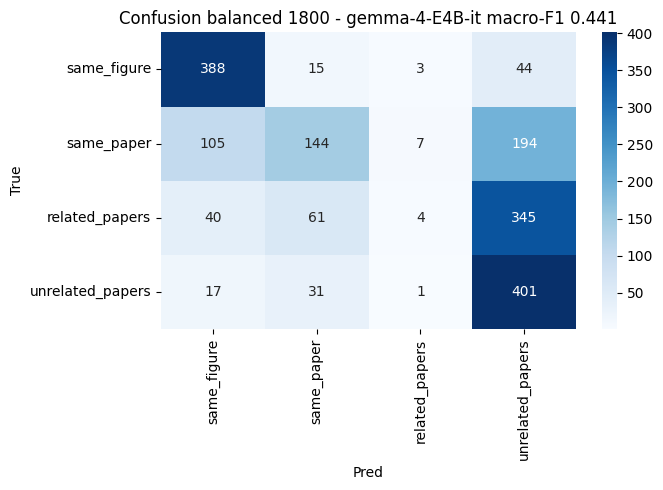

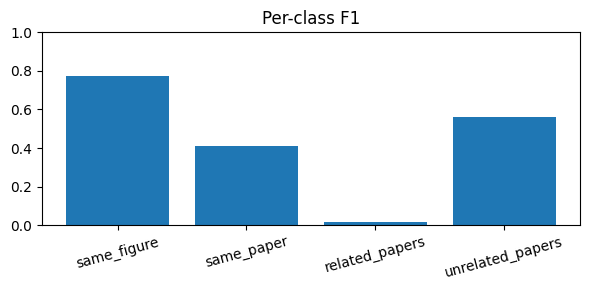

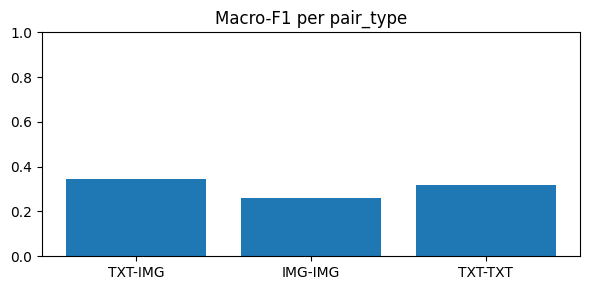

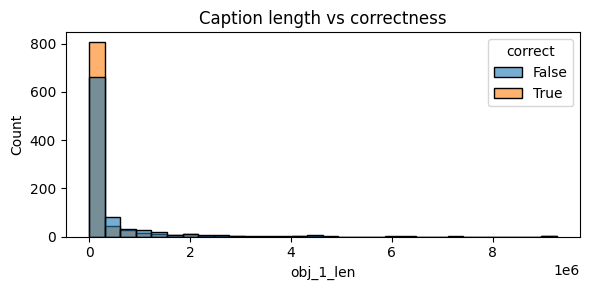

Saved plots


In [11]:
# --- 9. Visualization ---
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_cols, yticklabels=label_cols)
plt.title(f"Confusion balanced 1800 - {MODEL_ID.split('/')[-1]} macro-F1 {macro_f1:.3f}")
plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.savefig("confusion.png", dpi=150); plt.show()

plt.figure(figsize=(6,3))
plt.bar(label_cols, per_class)
plt.title("Per-class F1"); plt.ylim(0,1); plt.xticks(rotation=15); plt.tight_layout(); plt.savefig("per_class_f1.png"); plt.show()

# Per pair_type F1
pts, f1s = [], []
for pt in ["TXT-IMG","IMG-IMG","TXT-TXT"]:
    mask = train_bal["pair_type"]==pt
    f1s.append(f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0))
    pts.append(pt)
plt.figure(figsize=(6,3))
plt.bar(pts, f1s)
plt.title("Macro-F1 per pair_type"); plt.ylim(0,1); plt.tight_layout(); plt.savefig("per_pair_f1.png"); plt.show()

# Caption length vs error
train_bal["correct"] = (y_true == y_pred)
train_bal["obj_1_len"] = train_bal["obj_1"].astype(str).str.len()
plt.figure(figsize=(6,3))
sns.histplot(data=train_bal, x="obj_1_len", hue="correct", bins=30, alpha=0.6)
plt.title("Caption length vs correctness"); plt.tight_layout(); plt.savefig("len_vs_correct.png"); plt.show()
print("Saved plots")

In [12]:
# --- 10. 6.5h guard + summary (5-7h test) ---
elapsed = (time.time()-start_time)/3600
print(f"Elapsed {elapsed:.2f}h / 6.5h budget, remaining {6.5-elapsed:.2f}h")
print(f"Model {MODEL_ID} batch {BATCH_SIZE} thinking {ENABLE_THINKING} on balanced 1800 (450/class)")
print(f"Balanced macro-F1 {macro_f1:.4f} -> full 10k would be ~34h at 12s/it, use true batch 4 or 4B model for 9h")
print("Outputs: preds_train_bal_final.npy, metrics.json, confusion.png")


Elapsed 5.90h / 6.5h budget, remaining 0.60h
Model google/gemma-4-E4B-it batch 1 thinking False on balanced 1800 (450/class)
Balanced macro-F1 0.4408 -> full 10k would be ~34h at 12s/it, use true batch 4 or 4B model for 9h
Outputs: preds_train_bal_final.npy, metrics.json, confusion.png
